In [181]:
import os
import pandas as pd
import numpy as np
from shutil import copyfile , rmtree
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import pickle as pk

# Stage 1 : Data Processing 

In [158]:
output_dir = "/kaggle/working/"
input_dir = "/kaggle/input/datasets/faisalahmed07/pneumonia-chest-xray-dataset/Pneumonia_Dataset"


test_output = os.path.join(output_dir , 'test')
train_output = os.path.join(output_dir , 'train')



output_directories = [train_output , test_output]


remove_directories = True


if remove_directories:
    rmtree(test_output)
    rmtree(train_output)

if not os.path.exists(test_output):
    os.mkdir(test_output)
if not os.path.exists(train_output):
    os.mkdir(train_output)

In [159]:
class_mapping = {'NORMAL' : 0 , 'Bacterial' : 1 , 'Virus' : 1 , 'PNEUMONIA' : 1}
class_count = {0 : 0 , 1 : 0}
for root , directories , files in os.walk(input_dir):
    for file in files:
        category = root.split('/')[-1]
        class_num = class_mapping.get(category , -1)
        if class_num != -1:
            class_count[class_num] = class_count[class_num] + 1


In [160]:
training_size = 0.8
maximum_training_size = int(min(class_count.values()) * training_size)
classes = [[] , []]
training_count = {0 : 0 , 1 : 0}
testing_count = {0:0 , 1 : 0}
training_index = 0
testing_index = 0
for root , directories , files in os.walk(input_dir):
    for file in files:

        full_input_path = os.path.join(root , file)
        class_name = full_input_path.split("/")[-2]
        class_number = class_mapping.get(class_name , -1)
        if class_number != -1:
            if training_count[class_number] <= maximum_training_size:
                copyfile(full_input_path , os.path.join(train_output , f"{training_index}.jpeg" ))
                classes[0].append(class_number)
                training_count[class_number] = training_count[class_number] + 1
                training_index += 1
            else:
                copyfile(full_input_path , os.path.join(test_output , f"{testing_index}.jpeg" ))
                classes[1].append(class_number)
                testing_count[class_number] = testing_count[class_number] + 1
                testing_index += 1


In [161]:
class ChestDataset(data.Dataset):
    def __init__(self , output_dir , classes , transform = None) :
        self.output_dir = output_dir
        self.classes = classes
        self.transform = transform

    def __len__(self):
        return len(self.classes)

    def __getitem__(self , idx):
        full_file_path = os.path.join(self.output_dir , f"{idx}.jpeg")
        image = Image.open(full_file_path)
        image_class = self.classes[idx]

        if self.transform is not None:
            image = self.transform(image)

        # if image.shape[0] != 1:
        #     print(f"image: {idx} , shape : {image.shape}")
        return image , np.float32(image_class)

In [162]:
transform = transforms.Compose([
    # PIL tranformations
    transforms.Grayscale(1),
    transforms.Pad(50),
    transforms.Resize(200),
    transforms.CenterCrop(200),

    # Tranforming PIL to tensor
    transforms.ToTensor(),
    
    # Numpy transofmations
    
])

train_dataset = ChestDataset(output_directories[0] , classes[0] , transform = transform)
test_dataset= ChestDataset(output_directories[1] , classes[1] , transform = transform)


test_loader = data.DataLoader(test_dataset , batch_size = 32 , shuffle = False)
train_loader = data.DataLoader(train_dataset , batch_size = 32 , shuffle = True)

In [163]:
def plot_images(dataset , N = 6):
    fig = plt.figure(figsize = [(int(N/2) + 1) * 10 , 10])

    for i in range(N):
        ax = fig.add_subplot(2 , int(N / 2) + 1 , i + 1)
        image = np.array(dataset[i][0])
        class_num = dataset[i][1]
        image = image.reshape((image.shape[1] , image.shape[2] , image.shape[0]))
        ax.imshow(image , cmap = 'gray')
        ax.set_title(f"class : {class_num}")
    plt.show()

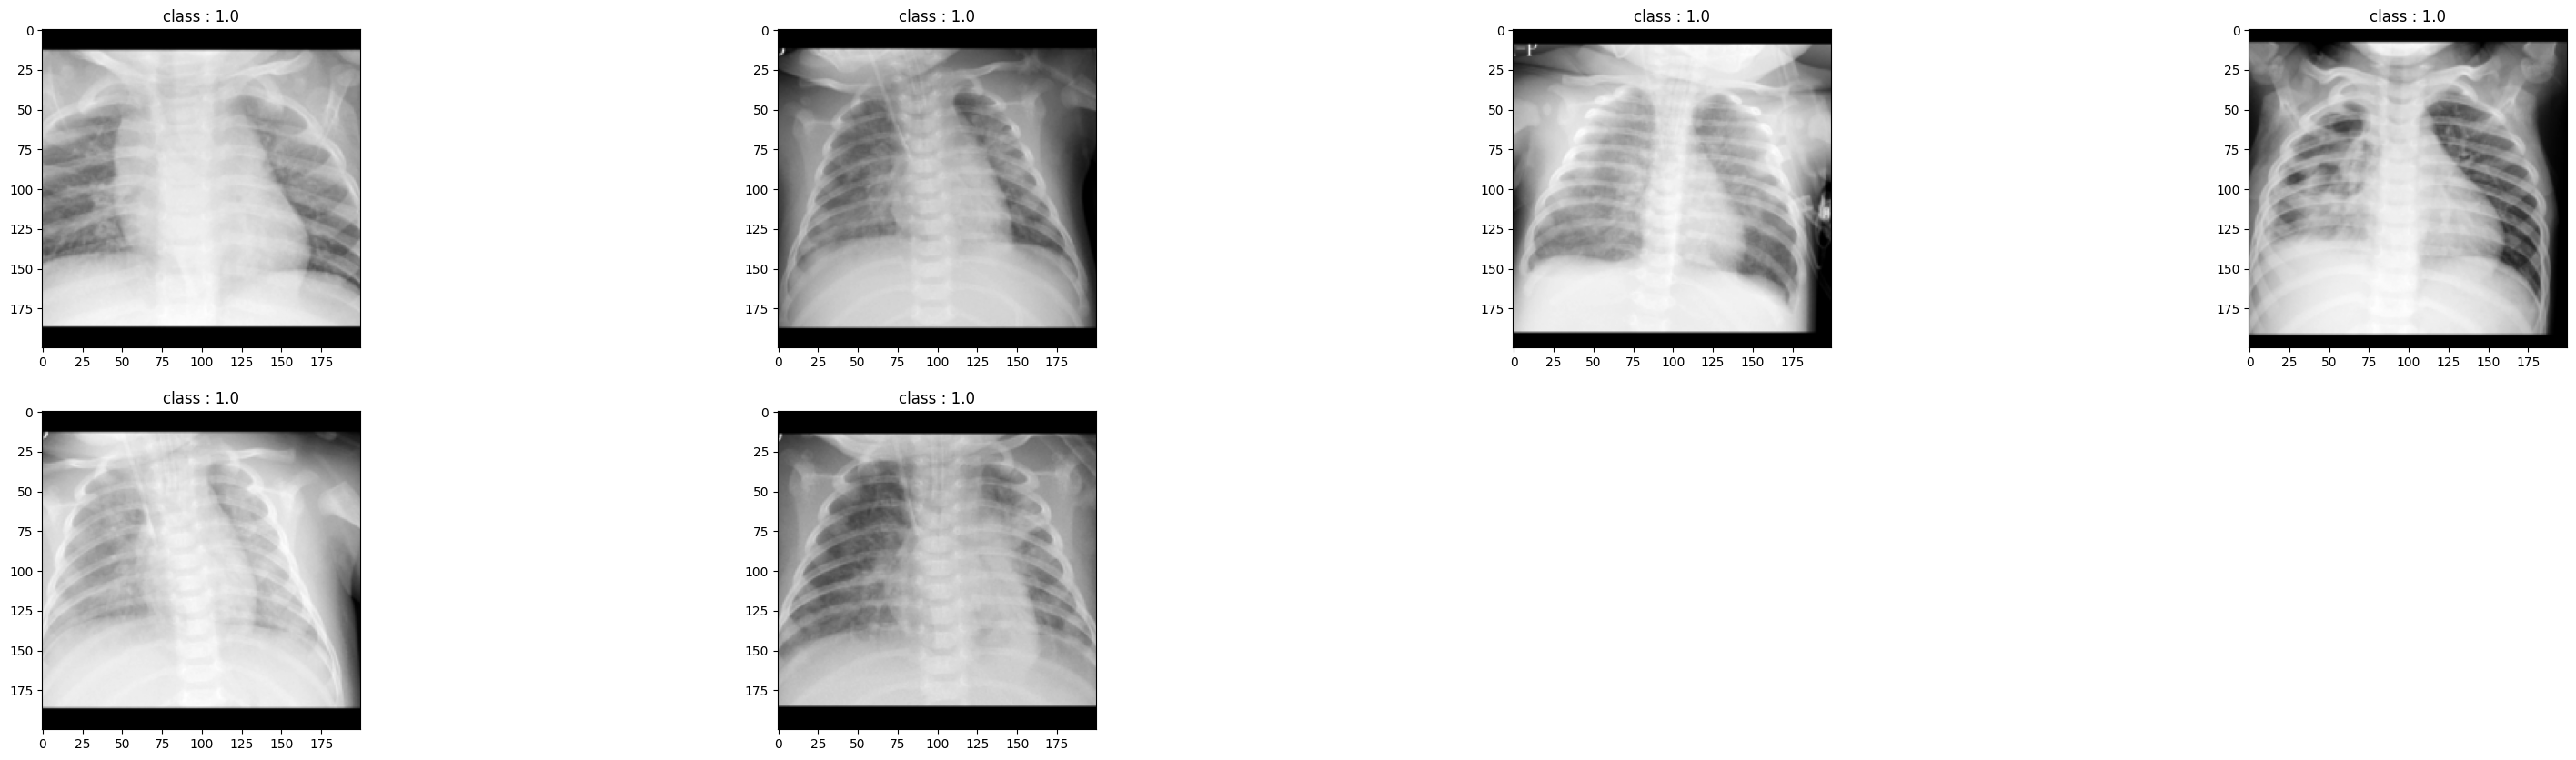

In [164]:
plot_images(train_dataset , 6)

# Stage 2 : Building the model

In [172]:
class PneumoniaClasifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.Conv_Sequential = nn.Sequential( # input : 200 * 200 * 1
            nn.Conv2d(1 , 30 , 3 , stride = 2), # output : 99 * 99 * 30
            nn.ReLU(),
            nn.Conv2d(30 , 20 , 3 , stride = 2), # output : 49 * 49 * 20
            nn.ReLU(),
            nn.MaxPool2d(3 , stride = 1), # output : 47 * 47 * 20
            nn.Conv2d(20 , 30 , 3 , stride = 1), # output : 45 * 45 * 30
            nn.ReLU(),
            nn.Conv2d(30 , 20 , 3 , stride = 1), # output : 43 * 43 * 20
            nn.ReLU(),
            nn.MaxPool2d(3 , stride = 1) # output : 41 * 41 * 20
        )
        
        self.Flatten = nn.Flatten()
        
        self.FC = nn.Sequential(
            nn.Linear(33620 , 100),
            nn.ReLU(),
            nn.Linear(100 ,50),
            nn.ReLU(),
            nn.Linear(50 , 20),
            nn.ReLU(),
            nn.Linear(20 , 1),
            nn.Sigmoid()
        )

    def forward(self , x):
        x = self.Conv_Sequential(x)
        
        x = self.Flatten(x)
       
        x = self.FC(x)

        return x
        
        

In [173]:
model = PneumoniaClasifier()

In [174]:
loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters() , lr = 0.0001)

In [177]:
def train_epoch(model , loss_function , optimizer , train_loader):
    model.train()
    total_loss = 0
    total_number_of_batches = len(train_loader)
    batch_num = 1
    
    for batch , targets in train_loader:

        print(f"Batch:{batch_num}/{total_number_of_batches}")
        optimizer.zero_grad()
        
        outputs = model(batch)


        
        loss = loss_function(outputs.squeeze() , targets)
        
        loss.backward()

        optimizer.step()
        total_loss += loss.item()
        batch_num += 1
    
    average_loss = total_loss/len(train_loader)

    return model , average_loss
    

In [178]:
def evaluate(model , test_loader , threshold = 0.5):
    model.eval()
    correct = 0
    total = 0 

    for batch , targets in test_loader:
        
        outputs = model(batch)
        outputs = (outputs > threshold).int().squeeze()
        correct_predictions = outputs.eq(targets).sum()
        correct += correct_predictions
        total += len(targets)

    accuracy = correct/total

    return accuracy 
    

# Section 3 : Training Model

In [179]:
EPOCHS = 10
losses = []
accuracies = []
for i in range(EPOCHS):
    print(f"[TRAINING] : {i + 1}/{EPOCHS}")
    
    trained_model , average_loss = train_epoch(model , loss_function , optimizer , train_loader)

    print(f"[EVALUATION] : {i + 1}/{EPOCHS}")

    accuracy = evaluate(model , test_loader , threshold = 0.5)

    accuracies.append(accuracy) 
    losses.append(average_loss)

    print(f"EPOCH[{i + 1}/{EPOCHS}]: accuracy : {accuracy} , loss : {average_loss} ")

[TRAINING] : 1/10
Batch:1/80
Batch:2/80
Batch:3/80
Batch:4/80
Batch:5/80
Batch:6/80
Batch:7/80
Batch:8/80
Batch:9/80
Batch:10/80
Batch:11/80
Batch:12/80
Batch:13/80
Batch:14/80
Batch:15/80
Batch:16/80
Batch:17/80
Batch:18/80
Batch:19/80
Batch:20/80
Batch:21/80
Batch:22/80
Batch:23/80
Batch:24/80
Batch:25/80
Batch:26/80
Batch:27/80
Batch:28/80
Batch:29/80
Batch:30/80
Batch:31/80
Batch:32/80
Batch:33/80
Batch:34/80
Batch:35/80
Batch:36/80
Batch:37/80
Batch:38/80
Batch:39/80
Batch:40/80
Batch:41/80
Batch:42/80
Batch:43/80
Batch:44/80
Batch:45/80
Batch:46/80
Batch:47/80
Batch:48/80
Batch:49/80
Batch:50/80
Batch:51/80
Batch:52/80
Batch:53/80
Batch:54/80
Batch:55/80
Batch:56/80
Batch:57/80
Batch:58/80
Batch:59/80
Batch:60/80
Batch:61/80
Batch:62/80
Batch:63/80
Batch:64/80
Batch:65/80
Batch:66/80
Batch:67/80
Batch:68/80
Batch:69/80
Batch:70/80
Batch:71/80
Batch:72/80
Batch:73/80
Batch:74/80
Batch:75/80
Batch:76/80
Batch:77/80
Batch:78/80
Batch:79/80
Batch:80/80
[EVALUATION] : 1/10
EPOCH[1/10]